# Практическая работа №2. Исследование атак на модели ИИ. FGSM

Выполнил Мерзликин Максим Ильич, ББМО-01-23

## Загрузка обученной модели

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(_, _), (test_images, test_labels) = mnist.load_data()

test_images = test_images / 255.0
test_labels = to_categorical(test_labels)
model = tf.keras.models.load_model('mnist_model.h5')
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy on clean images: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - accuracy: 0.9717 - loss: 0.0868
Test accuracy on clean images: 0.9767000079154968


## Реализация атаки FGSM

In [3]:
import numpy as np

# Функция для реализации FGSM атаки
def fgsm_attack(image, epsilon, gradient):
    # Применение знака градиента к изображению
    perturbed_image = image + epsilon * np.sign(gradient)
    # Обрезка значений, чтобы они оставались в пределах [0,1]
    perturbed_image = np.clip(perturbed_image, 0, 1)
    return perturbed_image
# Вычисление градиента
def generate_adversarial_example(model, image, label, epsilon):
    # Превращение изображения в формат, подходящий для модели
    image = tf.convert_to_tensor(image.reshape((1, 28, 28, 1)))
    label = tf.convert_to_tensor(label.reshape((1, 10)), dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = tf.keras.losses.categorical_crossentropy(label, prediction)
    # Получение градиента по отношению к входному изображению
    gradient = tape.gradient(loss, image)
    # Применение FGSM
    adversarial_image = fgsm_attack(image.numpy(), epsilon, gradient.numpy())
    return adversarial_image

epsilon = 0.1 # Величина шума
adversarial_example = generate_adversarial_example(model, test_images[0],
test_labels[0], epsilon)

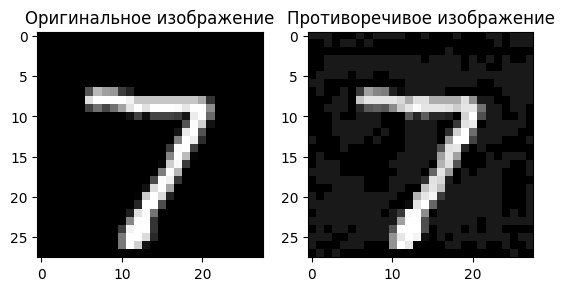

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.subplot(1, 2, 1)
plt.title("Оригинальное изображение")
plt.imshow(test_images[0], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Противоречивое изображение")
plt.imshow(adversarial_example.reshape(28, 28), cmap="gray")
plt.show()

In [5]:
# Генерация противоречивых примеров для всего набора данных
def generate_adversarial_dataset(model, images, labels, epsilon):
    adversarial_images = []
    for i in range(len(images)):
        adv_image = generate_adversarial_example(model, images[i], labels[i], epsilon)
        adversarial_images.append(adv_image.reshape(28,28))
    adversarial_images = np.array(adversarial_images)
    return adversarial_images

# Генерация противоречивых примеров

adversarial_images = generate_adversarial_dataset(model, test_images, test_labels,
epsilon)

# Оценка модели на противоречивых примерах
adversarial_loss, adversarial_acc = model.evaluate(adversarial_images,  test_labels)
print(f'Accuracy on adversarial examples: {adversarial_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0679 - loss: 7.2362
Accuracy on adversarial examples: 0.0949999988079071


## Вывод

После проведения FGSM-атаки точнось модели снизилась с 97.7% до 9.5%, что свидетельствует об успешности атаки и уязвимости модели к атакующими примерам.